# 🔬 Experiment 8: Random Forest Algorithm on Video Game Sales Dataset

Date: *20/03/2026*


---


## 🎯 Aim
To improve classification accuracy using ensemble learning with Random Forest algorithm.

## 📘 Theory

Random Forest creates multiple decision trees and combines their predictions:

- **Bagging (Bootstrap Aggregating)**: Each tree is trained on a random subset of data  
- **Feature Randomness**: Each split considers a random subset of features  
- **Majority Voting**: Final prediction is the mode of all tree predictions  

### Advantages:
- Reduces overfitting  
- Handles high dimensional data  
- Provides feature importance  
- Robust to noise and outliers  

## 📦 Import Libraries

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Load and Prepare Dataset

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("vgsales.csv")
df = df.dropna()

## 🎯 Creating Sales Categories

In [7]:
q1 = df['Global_Sales'].quantile(0.33)
q2 = df['Global_Sales'].quantile(0.66)

def sales_cat(x):
    if x <= q1:
        return 0
    elif x <= q2:
        return 1
    else:
        return 2

df['Sales_Class'] = df['Global_Sales'].apply(sales_cat)

## 🔍 Feature Selection

In [8]:
X = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
y = df['Sales_Class']

## ⚖️ Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## ✂️ Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

## 🌳 Creating Random Forest Model

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

## 🔁 Cross Validation

In [12]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation scores: [0.96931171 0.96185883 0.96185883 0.9627193  0.96491228]
Mean CV accuracy: 0.9641 (+/- 0.0056)


## 🧠 Training Model

In [13]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=42)

## 🔮 Prediction

In [14]:
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)

## 📊 Model Evaluation

In [15]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Low','Medium','High']
))

Accuracy: 0.9615384615384616

Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.96      0.96      1691
      Medium       0.93      0.95      0.94      1554
        High       0.99      0.97      0.98      1643

    accuracy                           0.96      4888
   macro avg       0.96      0.96      0.96      4888
weighted avg       0.96      0.96      0.96      4888



## 📌 Feature Importance

In [16]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
0,NA_Sales,0.457056
3,Other_Sales,0.216775
2,JP_Sales,0.178439
1,EU_Sales,0.147730


## 📈 Visualization: Feature Importance

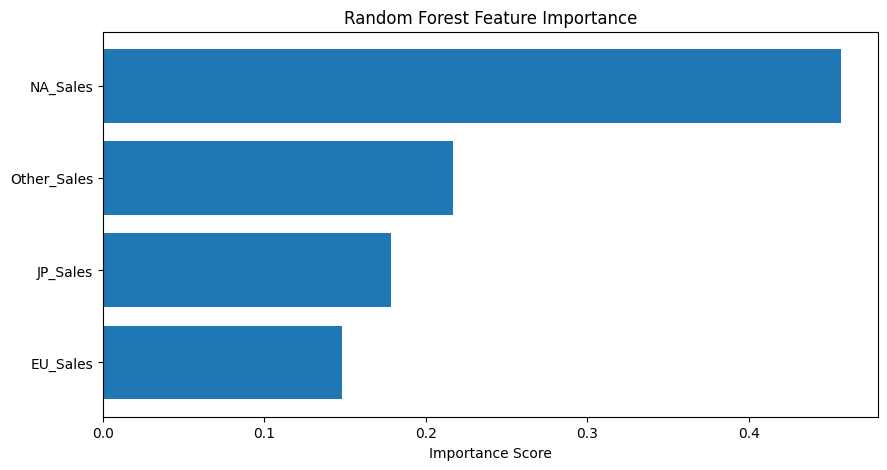

In [17]:
plt.figure(figsize=(10,5))

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.show()

## 🌲 Individual Tree Predictions

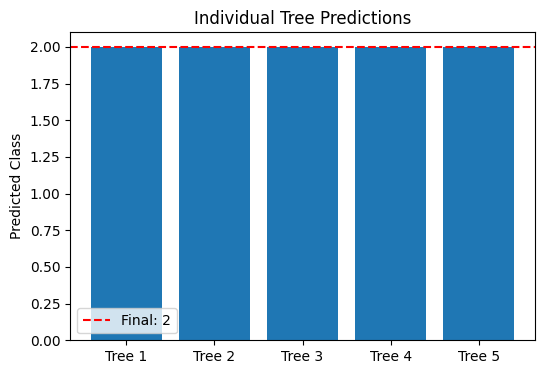

In [18]:
tree_predictions = []

for tree in rf.estimators_[:5]:
    tree_predictions.append(tree.predict(X_test[:1])[0])

x_pos = np.arange(len(tree_predictions))

plt.figure(figsize=(6,4))
plt.bar(x_pos, tree_predictions)

plt.xticks(x_pos, [f'Tree {i+1}' for i in range(len(tree_predictions))])
plt.ylabel('Predicted Class')
plt.title('Individual Tree Predictions')

final_pred = rf.predict(X_test[:1])[0]
plt.axhline(y=final_pred, color='red', linestyle='--',
            label=f'Final: {final_pred}')

plt.legend()
plt.show()

## 📉 OOB Error Analysis

In [19]:
rf_oob = RandomForestClassifier(
    warm_start=True,
    oob_score=True,
    random_state=42
)

oob_errors = []
n_estimators_range = range(10, 201, 10)

for n in n_estimators_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


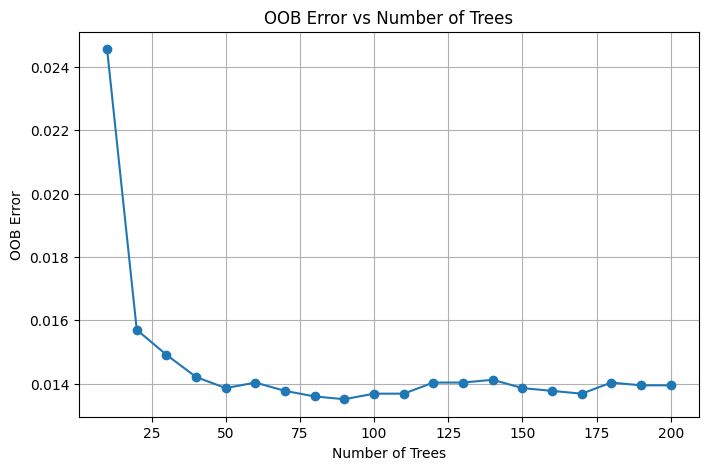

Final OOB Score: 0.986056300973428


In [20]:
plt.figure(figsize=(8,5))

plt.plot(n_estimators_range, oob_errors, 'o-')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error')
plt.title('OOB Error vs Number of Trees')
plt.grid(True)

plt.show()

print("Final OOB Score:", rf_oob.oob_score_)

## ✅ Result
Random Forest model improved classification performance using ensemble learning.

## 🏁 Conclusion
Random Forest enhances model accuracy by combining multiple decision trees and reducing overfitting.